# Molecular Dynamics Simulation using Gromacs 2023 in Cloud

Verificando os recursos disponíveis no Google Colab

In [ ]:
%%bash
lscpu
nvidia-smi

Architecture:                            x86_64
CPU op-mode(s):                          32-bit, 64-bit
Address sizes:                           46 bits physical, 48 bits virtual
Byte Order:                              Little Endian
CPU(s):                                  2
On-line CPU(s) list:                     0,1
Vendor ID:                               GenuineIntel
Model name:                              Intel(R) Xeon(R) CPU @ 2.00GHz
CPU family:                              6
Model:                                   85
Thread(s) per core:                      2
Core(s) per socket:                      1
Socket(s):                               1
Stepping:                                3
BogoMIPS:                                4000.44
Flags:                                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 clflush mmx fxsr sse sse2 ss ht syscall nx pdpe1gb rdtscp lm constant_tsc rep_good nopl xtopology nonstop_tsc cpuid tsc_known_freq 

## Instalando o gromacs

In [ ]:
%%bash
wget https://github.com/Kitware/CMake/releases/download/v3.20.0-rc1/cmake-3.20.0-rc1.tar.gz
tar xfz cmake-3.20.0-rc1.tar.gz

--2026-05-30 17:14:08--  https://github.com/Kitware/CMake/releases/download/v3.20.0-rc1/cmake-3.20.0-rc1.tar.gz
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/537699/06e77180-705e-11eb-8500-bec51c1075dc?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-05-30T17%3A57%3A20Z&rscd=attachment%3B+filename%3Dcmake-3.20.0-rc1.tar.gz&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-05-30T16%3A57%3A07Z&ske=2026-05-30T17%3A57%3A20Z&sks=b&skv=2018-11-09&sig=gmh6dSRY9wlRFtocA9dzB8ya0fkLZe8IPOvfo8GqJBA%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4MDE2MTU0OCwibmJmIjoxNzgwMTYxMjQ4LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJv

In [ ]:
%%bash
mkdir /content/cmake-3.20.0-rc1/build
cd /content/cmake-3.20.0-rc1/build
cmake /content/cmake-3.20.0-rc1/
make -j 2
make install

-- The C compiler identification is GNU 11.4.0
-- The CXX compiler identification is GNU 11.4.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/bin/c++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Checking if compiler supports C11 _Thread_local
-- Checking if compiler supports C11 _Thread_local - yes
-- Checking if compiler supports needed C++17 constructs
-- Checking if compiler supports needed C++17 constructs - yes
-- Checking if compiler supports C++ make_unique
-- Checking if compiler supports C++ make_unique - yes
-- Checking if compiler supports C++ filesystem
-- Checking if compiler supports C++ filesystem - yes
-- Looking for unsetenv
-- Looking for unsetenv - found
-- Lo

CMake Warning (dev) at /usr/local/lib/python3.12/dist-packages/cmake/data/share/cmake-3.31/Modules/Dart.cmake:47 (message):
  Policy CMP0145 is not set: The Dart and FindDart modules are removed.  Run
  "cmake --help-policy CMP0145" for policy details.  Use the cmake_policy
  command to set the policy and suppress this warning.
Call Stack (most recent call first):
  CMakeLists.txt:714 (include)
This warning is for project developers.  Use -Wno-dev to suppress it.

CMake Deprecation Warning at Source/kwsys/CMakeLists.txt:89 (cmake_minimum_required):
  Compatibility with CMake < 3.10 will be removed from a future version of
  CMake.

  Update the VERSION argument <min> value.  Or, use the <min>...<max> syntax
  to tell CMake that the project requires at least <min> but has been updated
  to work with policies introduced by <max> or earlier.


CMake Deprecation Warning at /content/cmake-3.20.0-rc1/Source/Checks/Curses/CMakeLists.txt:1 (cmake_minimum_required):
  Compatibility with CMake <

In [ ]:
%%bash
cmake --version

cmake version 3.20.0-rc1

CMake suite maintained and supported by Kitware (kitware.com/cmake).


In [ ]:
%%bash
wget ftp://ftp.gromacs.org/gromacs/gromacs-2023.2.tar.gz
tar xfz gromacs-2023.2.tar.gz
cd /content/gromacs-2023.2
mkdir /content/gromacs-2023.2/build
cd /content/gromacs-2023.2/build
# with cpu
cmake .. -DGMX_BUILD_OWN_FFTW=ON -DREGRESSIONTEST_DOWNLOAD=ON -DGMX_GPU=OFF -DGMX_SIMD=AVX2_256
# with gpu
#cmake .. -DGMX_BUILD_OWN_FFTW=ON -DREGRESSIONTEST_DOWNLOAD=ON -DGMX_GPU=CUDA
make -j 2
make install
source /usr/local/gromacs/bin/GMXRC

-- The GROMACS-managed build of FFTW 3 will configure with the following optimizations: --enable-sse2;--enable-avx;--enable-avx2
-- Using external FFT library - FFTW3 build managed by GROMACS
-- Looking for sgemm_
-- Looking for sgemm_ - not found
-- Looking for sgemm_
-- Looking for sgemm_ - found
-- Found BLAS: /usr/lib/x86_64-linux-gnu/libmkl_intel_lp64.so;/usr/lib/x86_64-linux-gnu/libmkl_intel_thread.so;/usr/lib/x86_64-linux-gnu/libmkl_core.so;/usr/local/lib/libiomp5.so;-lm;-ldl  
-- Looking for cheev_
-- Looking for cheev_ - found
-- Found LAPACK: /usr/lib/x86_64-linux-gnu/libmkl_intel_lp64.so;/usr/lib/x86_64-linux-gnu/libmkl_intel_thread.so;/usr/lib/x86_64-linux-gnu/libmkl_core.so;/usr/local/lib/libiomp5.so;-lm;-ldl;-lm;-ldl  
-- Could not convert sample image, ImageMagick convert can not be used. A possible way to fix it can be found here: https://alexvanderbist.com/2018/fixing-imagick-error-unauthorized
-- Performing Test HAS_WARNING_EVERYTHING
-- Performing Test HAS_WARNING_EV

mkdir: cannot create directory ‘/content/gromacs-2023.2/build’: File exists
Downloading: https://ftp.gromacs.org/regressiontests/regressiontests-2023.2.tar.gz
ar: `u' modifier ignored since `D' is the default (see `U')
ar: `u' modifier ignored since `D' is the default (see `U')
ar: `u' modifier ignored since `D' is the default (see `U')
ar: `u' modifier ignored since `D' is the default (see `U')
ar: `u' modifier ignored since `D' is the default (see `U')
ar: `u' modifier ignored since `D' is the default (see `U')
ar: `u' modifier ignored since `D' is the default (see `U')
ar: `u' modifier ignored since `D' is the default (see `U')
ar: `u' modifier ignored since `D' is the default (see `U')
ar: `u' modifier ignored since `D' is the default (see `U')
ar: `u' modifier ignored since `D' is the default (see `U')
ar: `u' modifier ignored since `D' is the default (see `U')
ar: `u' modifier ignored since `D' is the default (see `U')
ar: `u' modifier ignored since `D' is the default (see `U')
a

In [ ]:
%%bash
source /usr/local/gromacs/bin/GMXRC
mkdir /content/MDjobs
cd /content/MDjobs
gmx --version

                         :-) GROMACS - gmx, 2023.2 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content/MDjobs
Command line:
  gmx --version

GROMACS version:    2023.2
Precision:          mixed
Memory model:       64 bit
MPI library:        thread_mpi
OpenMP support:     enabled (GMX_OPENMP_MAX_THREADS = 128)
GPU support:        disabled
SIMD instructions:  AVX2_256
CPU FFT library:    fftw-3.3.8-sse2-avx-avx2-avx2_128
GPU FFT library:    none
Multi-GPU FFT:      none
RDTSCP usage:       enabled
TNG support:        enabled
Hwloc support:      disabled
Tracing support:    disabled
C compiler:         /usr/bin/cc GNU 11.4.0
C compiler flags:   -fexcess-precision=fast -funroll-all-loops -mavx2 -mfma -Wno-missing-field-initializers -O3 -DNDEBUG
C++ compiler:       /usr/bin/c++ GNU 11.4.0
C++ compiler flags: -fexcess-precision=fast -funroll-all-loops -mavx2 -mfma -Wno-missing-field-initializers -Wno-cast-function-type-strict -fopenmp -O3 -DN

mkdir: cannot create directory ‘/content/MDjobs’: File exists


In [ ]:
# Tornar a biblioteca do gromacs disponível para todos os processos seguintes
!export GMXLIB=/usr/local/share/gromacs/top


## Procedimento para rodar Dinâmica Molecular de proteinas em água

1. Preparação da estrutura 3D:
Utilizar uma das duas opções abaixo

> Estrutura do Protein Data Bank: Raios-X, RMN e/ou Cryo-EM
* Verificar resíduos e cadeias laterais ausentes na estrutura
* Remover componentes não proteicos como água, ligantes, íons metálicos, etc.

> Prever a estrutura 3D da proteína: Algoritmo baseado em homologia, Algoritmo de alinhamento por encadeamento, Algoritmo Ab-Initio (Aprendizado de Máquina)
Um exemplo de algoritmo de Aprendizado de Máquina é o AlphaFold da DeepMind
* Verificar a precisão da estrutura 3D

2. Preparação do arquivo de topologia da proteína
* Utilizar o Campo de Força - consultar a documentação do Gromacs ou Amber

3. Modelo de Solvatação e Ionização
- Sais, moléculas de água e outras moléculas ao redor da proteína (caixa de simulação)

4. Minimização de Energia (estado de menor energia possível/estrutura mais estável).
* Algoritmos:
> Descida Mais Íngreme (SD)
> Newton-Raphson com Base Adaptada (ABNR)

5. Estágio de Equilíbrio
* o sistema atinge o equilíbrio termodinâmico quando as propriedades médias (energia, densidade, T, P) param de variar com o tempo e passam a flutuar em torno de valores constantes (estado estacionário).
* o controle termodinâmico é aplicado via:
> Termostato(T): temperatura (NVT)\
> Barostato(P): (NPT)

6. Estágio de Produção
- **simulações** que duram de nanossegundos a alguns microssegundos (a meia-vida de uma proteína é muito curta)

Para fazer todo o procedimento com uma proteina do pdb utilize as duas próximas linhas de código abaixo:

In [ ]:
id_protein = "1AKI.pdb"
!wget http://files.rcsb.org/download/{id_protein} > prot.pdb

--2026-05-30 18:21:58--  http://files.rcsb.org/download/1AKI.pdb
Resolving files.rcsb.org (files.rcsb.org)... 18.172.21.104, 18.172.21.127, 18.172.21.89, ...
Connecting to files.rcsb.org (files.rcsb.org)|18.172.21.104|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/plain]
Saving to: ‘1AKI.pdb’

1AKI.pdb                [  <=>               ] 113.67K   223KB/s    in 0.5s    

2026-05-30 18:21:59 (223 KB/s) - ‘1AKI.pdb’ saved [116397]



In [ ]:
#Remover componentes não proteicos como água, ligantes, íons metálicos, etc.
id_protein = "1AKI.pdb"
!grep -v HOH {id_protein} > prot_clean.pdb
'''
Nota se a estrutura do pdb tiver residuos ou cadeias laterais
você precisaria utilizar algum dos métodos de predição de estruturas
antes de prosseguir com os próximos passos.
'''

'\nNota se a estrutura do pdb tiver residuos ou cadeias laterais\nvocê precisaria utilizar algum dos métodos de predição de estruturas\nantes de prosseguir com os próximos passos.\n'

### Etapas 2 a 5 códigos utilizados em meu PC:

* Etapa 2 - Criação do arquivo de topologia

```
%%bash
source /usr/local/gromacs/bin/GMXRC
gmx pdb2gmx -f prot_clean.pdb -o prot_processed.gro -water spce -ff oplsaa
```

* Etapa 3 - Solvatação:

3.1
```
%%bash
source /usr/local/gromacs/bin/GMXRC
gmx editconf -f prot_processed.gro -o prot_newbox.gro -c -d 1.0 -bt cubic
```
3.2
```
%%bash
source /usr/local/gromacs/bin/GMXRC
gmx solvate -cp prot_newbox.gro -cs spc216.gro -o prot_solv.gro -p topol.top
```
* Etapa 3 - Ionização:

3.1
```
%%bash
source /usr/local/gromacs/bin/GMXRC
gmx grompp -f ions.mdp -c prot_solv.gro -p topol.top -o ions.tpr
```
3.2
```
%%bash
source /usr/local/gromacs/bin/GMXRC
printf "SOL" | gmx genion -s ions.tpr -o prot_solv_ions.gro -p topol.top -pname NA -nname CL -neutral
```
* Etapa 4 - Minimização de Energia:

4.1
```
%%bash
source /usr/local/gromacs/bin/GMXRC
gmx grompp -f minim.mdp -c prot_solv_ions.gro -p topol.top -o em.tpr
```
4.2
```
%%bash
source /usr/local/gromacs/bin/GMXRC
gmx mdrun -v -deffnm em
```
* Etapa 5 - Equilíbrio:

Termostato(T)

5.1
```
%%bash
source /usr/local/gromacs/bin/GMXRC
gmx grompp -f nvt.mdp -c em.gro -r em.gro -p topol.top -o nvt.tpr
```
5.2
```
%%bash
source /usr/local/gromacs/bin/GMXRC
gmx mdrun -v -deffnm nvt
```

Para plotar a energia utilize o seguinte comando
```
%%bash
source /usr/local/gromacs/bin/GMXRC
gmx energy -f nvt.edr -o temperature.xvg
```
Barostato(P)

5.3
```
%%bash
source /usr/local/gromacs/bin/GMXRC
gmx grompp -f npt.mdp -c nvt.gro -r nvt.gro -t nvt.cpt -p topol.top -o npt.tpr

```

5.4
```
%%bash
source /usr/local/gromacs/bin/GMXRC
gmx mdrun -v -deffnm npt
```
Para plotar a energia utilize o seguinte comando
```
%%bash
source /usr/local/gromacs/bin/GMXRC
gmx energy -f npt.edr -o pressure.xvg
```

* Etapa 6 - Produção:

6.1
```
%%bash
source /usr/local/gromacs/bin/GMXRC
gmx grompp -f md.mdp -c npt.gro -t npt.cpt -p topol.top -o md_0_1.tpr
```

6.2
```
%%bash
source /usr/local/gromacs/bin/GMXRC
gmx mdrun -deffnm md_0_1 -v -nb gpu
```

Etapa 2 - Criação do arquivo de topologia

In [ ]:
%%bash
source /usr/local/gromacs/bin/GMXRC
gmx pdb2gmx -f prot_clean.pdb -o prot_processed.gro -water spce -ff oplsaa

Using the Oplsaa force field in directory oplsaa.ff

going to rename oplsaa.ff/aminoacids.r2b
Reading prot_clean.pdb...
Read 'LYSOZYME', 1001 atoms

Analyzing pdb file
Splitting chemical chains based on TER records or chain id changing.

There are 1 chains and 0 blocks of water and 129 residues with 1001 atoms

  chain  #res #atoms

  1 'A'   129   1001  

All occupancies are one

Reading residue database... (Oplsaa)

Processing chain 1 'A' (1001 atoms, 129 residues)

Identified residue LYS1 as a starting terminus.

Identified residue LEU129 as a ending terminus.
Start terminus LYS-1: NH3+
End terminus LEU-129: COO-

Checking for duplicate atoms....

Generating any missing hydrogen atoms and/or adding termini.

Now there are 129 residues with 1960 atoms

Making bonds...

Number of bonds was 1984, now 1984

Generating angles, dihedrals and pairs...

Making cmap torsions...

There are 5187 dihedrals,  426 impropers, 3547 angles
          5106 pairs,     1984 bonds and     0 virtual sites

                     :-) GROMACS - gmx pdb2gmx, 2023.2 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content
Command line:
  gmx pdb2gmx -f prot_clean.pdb -o prot_processed.gro -water spce -ff oplsaa

Opening force field file /usr/local/gromacs/share/gromacs/top/oplsaa.ff/aminoacids.r2b
All occupancies are one
Opening force field file /usr/local/gromacs/share/gromacs/top/oplsaa.ff/atomtypes.atp
Opening force field file /usr/local/gromacs/share/gromacs/top/oplsaa.ff/aminoacids.rtp
Opening force field file /usr/local/gromacs/share/gromacs/top/oplsaa.ff/aminoacids.hdb
Opening force field file /usr/local/gromacs/share/gromacs/top/oplsaa.ff/aminoacids.n.tdb
Opening force field file /usr/local/gromacs/share/gromacs/top/oplsaa.ff/aminoacids.c.tdb
Analysing hydrogen-bonding network for automated assignment of histidine
 protonation. 213 donors and 184 acceptors were found.
There are 255 hydrogen bonds
Will use HISE for residue 15
8 out of 8 lines

Etapa 3 - Solvatação e Ionização

In [ ]:
%%bash
source /usr/local/gromacs/bin/GMXRC
gmx editconf -f prot_processed.gro -o prot_newbox.gro -c -d 1.0 -bt cubic

Note that major changes are planned in future for editconf, to improve usability and utility.
Read 1960 atoms
Volume: 123.376 nm^3, corresponds to roughly 55500 electrons
No velocities found
    system size :  3.817  4.234  3.454 (nm)
    diameter    :  5.010               (nm)
    center      :  2.781  2.488  0.017 (nm)
    box vectors :  5.906  6.845  3.052 (nm)
    box angles  :  90.00  90.00  90.00 (degrees)
    box volume  : 123.38               (nm^3)
    shift       :  0.724  1.017  3.488 (nm)
new center      :  3.505  3.505  3.505 (nm)
new box vectors :  7.010  7.010  7.010 (nm)
new box angles  :  90.00  90.00  90.00 (degrees)
new box volume  : 344.48               (nm^3)


                     :-) GROMACS - gmx editconf, 2023.2 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content
Command line:
  gmx editconf -f prot_processed.gro -o prot_newbox.gro -c -d 1.0 -bt cubic


GROMACS reminds you: "It's more useful when you know what you're doing." (Artem Zhmurov)



In [ ]:
%%bash
source /usr/local/gromacs/bin/GMXRC
gmx solvate -cp prot_newbox.gro -cs spc216.gro -o prot_solv.gro -p topol.top


         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary. Note, that this functionality may
         be removed in a future GROMACS version. Please, consider
         using another file format for your input.

NOTE: From version 5.0 gmx solvate uses the Van der Waals radii
from the source below. This means the results may be different
compared to previous GROMACS versions.

++++ PLEASE READ AND CITE THE FOLLOWING REFERENCE ++++
A. Bondi
van der Waals Volumes and Radii
J. Phys. Chem. 68 (1964) pp. 441-451
-------- -------- --- Thank You --- -------- --------

Adding line for 10644 solvent molecules with resname (SOL) to topology file (topol.top)


                     :-) GROMACS - gmx solvate, 2023.2 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content
Command line:
  gmx solvate -cp prot_newbox.gro -cs spc216.gro -o prot_solv.gro -p topol.top

Reading solute configuration
Reading solvent configuration

Initialising inter-atomic distances...
Generating solvent configuration
Will generate new solvent configuration of 4x4x4 boxes
Solvent box contains 39252 atoms in 13084 residues
Removed 5451 solvent atoms due to solvent-solvent overlap
Removed 1869 solvent atoms due to solute-solvent overlap
Sorting configuration
Found 1 molecule type:
    SOL (   3 atoms): 10644 residues
Generated solvent containing 31932 atoms in 10644 residues
Writing generated configuration to prot_solv.gro

Output configuration contains 33892 atoms in 10773 residues
Volume                 :     344.484 (nm^3)
Density                :     997.935 (g/l)
Number of solvent molecules:  10644   

Processing topolog

In [ ]:
# ions.mdp configuration
ions_config = """; ions.mdp - used as input into grompp to generate ions.tpr
; Parameters describing what to do, when to stop and what to save
integrator  = steep         ; Algorithm (steep = steepest descent minimization)
emtol       = 1000.0        ; Stop minimization when the maximum force < 1000.0 kJ/mol/nm
emstep      = 0.01          ; Minimization step size
nsteps      = 50000         ; Maximum number of (minimization) steps to perform

; Parameters describing how to find the neighbors of each atom and how to calculate the interactions
nstlist         = 1         ; Frequency to update the neighbor list and long range forces
cutoff-scheme	= Verlet    ; Buffered neighbor searching
ns_type         = grid      ; Method to determine neighbor list (simple, grid)
coulombtype     = cutoff    ; Treatment of long range electrostatic interactions
rcoulomb        = 1.0       ; Short-range electrostatic cut-off
rvdw            = 1.0       ; Short-range Van der Waals cut-off
pbc             = xyz       ; Periodic Boundary Conditions in all 3 dimensions
"""
with open('ions.mdp', 'w') as f:
    f.write(ions_config)
!cat ions.mdp

; ions.mdp - used as input into grompp to generate ions.tpr
; Parameters describing what to do, when to stop and what to save
integrator  = steep         ; Algorithm (steep = steepest descent minimization)
emtol       = 1000.0        ; Stop minimization when the maximum force < 1000.0 kJ/mol/nm
emstep      = 0.01          ; Minimization step size
nsteps      = 50000         ; Maximum number of (minimization) steps to perform

; Parameters describing how to find the neighbors of each atom and how to calculate the interactions
nstlist         = 1         ; Frequency to update the neighbor list and long range forces
cutoff-scheme	= Verlet    ; Buffered neighbor searching
ns_type         = grid      ; Method to determine neighbor list (simple, grid)
coulombtype     = cutoff    ; Treatment of long range electrostatic interactions
rcoulomb        = 1.0       ; Short-range electrostatic cut-off
rvdw            = 1.0       ; Short-range Van der Waals cut-off
pbc             = xyz       ; Perio

In [ ]:
%%bash
source /usr/local/gromacs/bin/GMXRC
gmx grompp -f ions.mdp -c prot_solv.gro -p topol.top -o ions.tpr

Setting the LD random seed to -1107362850

Generated 330891 of the 330891 non-bonded parameter combinations

Generated 330891 of the 330891 1-4 parameter combinations

Excluding 3 bonded neighbours molecule type 'Protein_chain_A'

Excluding 2 bonded neighbours molecule type 'SOL'
Analysing residue names:
There are:   129    Protein residues
There are: 10644      Water residues
Analysing Protein...

This run will generate roughly 3 Mb of data


                      :-) GROMACS - gmx grompp, 2023.2 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content
Command line:
  gmx grompp -f ions.mdp -c prot_solv.gro -p topol.top -o ions.tpr

Ignoring obsolete mdp entry 'ns_type'

NOTE 1 [file ions.mdp]:
  With Verlet lists the optimal nstlist is >= 10, with GPUs >= 20. Note
  that with the Verlet scheme, nstlist has no effect on the accuracy of
  your simulation.

Generating 1-4 interactions: fudge = 0.5

NOTE 2 [file topol.top, line 18409]:
  System has non-zero total charge: 8.000000
  Total charge should normally be an integer. See
  http://www.gromacs.org/Documentation/Floating_Point_Arithmetic
  for discussion on how close it should be to an integer.



Number of degrees of freedom in T-Coupling group rest is 69741.00
The integrator does not provide a ensemble temperature, there is no system ensemble temperature

NOTE 3 [file ions.mdp]:
  You are using a plain Coulomb cut-off, which 

In [ ]:
%%bash
source /usr/local/gromacs/bin/GMXRC
printf "SOL" | gmx genion -s ions.tpr -o prot_solv_ions.gro -p topol.top -pname NA -nname CL -neutral

Will try to add 0 NA ions and 8 CL ions.
Select a continuous group of solvent molecules
Selected 13: 'SOL'

Processing topology
Replacing 8 solute molecules in topology file (topol.top)  by 0 NA and 8 CL ions.


                      :-) GROMACS - gmx genion, 2023.2 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content
Command line:
  gmx genion -s ions.tpr -o prot_solv_ions.gro -p topol.top -pname NA -nname CL -neutral

Reading file ions.tpr, VERSION 2023.2 (single precision)
Reading file ions.tpr, VERSION 2023.2 (single precision)
Group     0 (         System) has 33892 elements
Group     1 (        Protein) has  1960 elements
Group     2 (      Protein-H) has  1001 elements
Group     3 (        C-alpha) has   129 elements
Group     4 (       Backbone) has   387 elements
Group     5 (      MainChain) has   517 elements
Group     6 (   MainChain+Cb) has   634 elements
Group     7 (    MainChain+H) has   646 elements
Group     8 (      SideChain) has  1314 elements
Group     9 (    SideChain-H) has   484 elements
Group    10 (    Prot-Masses) has  1960 elements
Group    11 (    non-Protein) has 31932 elements
Group    12 (          Water) has 319

Etapa 4 - Minimização de Energia

In [ ]:
# minim.mdp configuration
minim_config = """; minim.mdp - used as input into grompp to generate em.tpr
; Parameters describing what to do, when to stop and what to save
integrator  = steep         ; Algorithm (steep = steepest descent minimization)
emtol       = 1000.0        ; Stop minimization when the maximum force < 1000.0 kJ/mol/nm
emstep      = 0.01          ; Minimization step size
nsteps      = 50000         ; Maximum number of (minimization) steps to perform

; Parameters describing how to find the neighbors of each atom and how to calculate the interactions
nstlist         = 1         ; Frequency to update the neighbor list and long range forces
cutoff-scheme   = Verlet    ; Buffered neighbor searching
ns_type         = grid      ; Method to determine neighbor list (simple, grid)
coulombtype     = PME       ; Treatment of long range electrostatic interactions
rcoulomb        = 1.0       ; Short-range electrostatic cut-off
rvdw            = 1.0       ; Short-range Van der Waals cut-off
pbc             = xyz       ; Periodic Boundary Conditions in all 3 dimensions
"""
with open('minim.mdp', 'w') as f:
    f.write(ions_config)
!cat minim.mdp

; ions.mdp - used as input into grompp to generate ions.tpr
; Parameters describing what to do, when to stop and what to save
integrator  = steep         ; Algorithm (steep = steepest descent minimization)
emtol       = 1000.0        ; Stop minimization when the maximum force < 1000.0 kJ/mol/nm
emstep      = 0.01          ; Minimization step size
nsteps      = 50000         ; Maximum number of (minimization) steps to perform

; Parameters describing how to find the neighbors of each atom and how to calculate the interactions
nstlist         = 1         ; Frequency to update the neighbor list and long range forces
cutoff-scheme	= Verlet    ; Buffered neighbor searching
ns_type         = grid      ; Method to determine neighbor list (simple, grid)
coulombtype     = cutoff    ; Treatment of long range electrostatic interactions
rcoulomb        = 1.0       ; Short-range electrostatic cut-off
rvdw            = 1.0       ; Short-range Van der Waals cut-off
pbc             = xyz       ; Perio

In [ ]:
%%bash
source /usr/local/gromacs/bin/GMXRC
gmx grompp -f minim.mdp -c prot_solv_ions.gro -p topol.top -o em.tpr

Setting the LD random seed to 2013265660

Generated 330891 of the 330891 non-bonded parameter combinations

Generated 330891 of the 330891 1-4 parameter combinations

Excluding 3 bonded neighbours molecule type 'Protein_chain_A'

Excluding 2 bonded neighbours molecule type 'SOL'

Excluding 1 bonded neighbours molecule type 'CL'
Analysing residue names:
There are:   129    Protein residues
There are: 10636      Water residues
There are:     8        Ion residues
Analysing Protein...

This run will generate roughly 3 Mb of data


                      :-) GROMACS - gmx grompp, 2023.2 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content
Command line:
  gmx grompp -f minim.mdp -c prot_solv_ions.gro -p topol.top -o em.tpr

Ignoring obsolete mdp entry 'ns_type'

NOTE 1 [file minim.mdp]:
  With Verlet lists the optimal nstlist is >= 10, with GPUs >= 20. Note
  that with the Verlet scheme, nstlist has no effect on the accuracy of
  your simulation.

Generating 1-4 interactions: fudge = 0.5
Number of degrees of freedom in T-Coupling group rest is 69717.00
The integrator does not provide a ensemble temperature, there is no system ensemble temperature

NOTE 2 [file minim.mdp]:
  You are using a plain Coulomb cut-off, which might produce artifacts.
  You might want to consider using PME electrostatics.



There were 2 NOTEs

GROMACS reminds you: "Baseball Heroes Only" (P.J. Harvey)



In [ ]:
%%bash
source /usr/local/gromacs/bin/GMXRC
gmx mdrun -v -deffnm em

                      :-) GROMACS - gmx mdrun, 2023.2 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content
Command line:
  gmx mdrun -v -deffnm em

Reading file em.tpr, VERSION 2023.2 (single precision)
Using 1 MPI thread
Using 2 OpenMP threads 


Steepest Descents:
   Tolerance (Fmax)   =  1.00000e+03
   Number of steps    =        50000
Step=    0, Dmax= 1.0e-02 nm, Epot= -3.32352e+05 Fmax= 2.28197e+05, atom= 1905
Step=    1, Dmax= 1.0e-02 nm, Epot= -3.48461e+05 Fmax= 8.63188e+04, atom= 19877
Step=    2, Dmax= 1.2e-02 nm, Epot= -3.70948e+05 Fmax= 3.29916e+04, atom= 19877
Step=    3, Dmax= 1.4e-02 nm, Epot= -3.99689e+05 Fmax= 1.30781e+04, atom= 24185
Step=    4, Dmax= 1.7e-02 nm, Epot= -4.29438e+05 Fmax= 5.58365e+03, atom= 983
Step=    5, Dmax= 2.1e-02 nm, Epot= -4.57340e+05 Fmax= 9.09255e+03, atom= 1905
Step=    6, Dmax= 2.5e-02 nm, Epot= -4.65056e+05 Fmax= 2.46937e+04, atom= 1905
Step=    7, Dmax= 3.0e-02 nm, Epot= -4.71310e+05 Fmax= 

Etapa 5 - Equilíbrio

In [ ]:
# nvt.mdp configuration
nvt_config = """title                   = OPLS Lysozyme NVT equilibration
define                  = -DPOSRES  ; position restrain the protein
; Run parameters
integrator              = md        ; leap-frog integrator
nsteps                  = 50000     ; 2 * 50000 = 100 ps
dt                      = 0.002     ; 2 fs
; Output control
nstxout                 = 500       ; save coordinates every 1.0 ps
nstvout                 = 500       ; save velocities every 1.0 ps
nstenergy               = 500       ; save energies every 1.0 ps
nstlog                  = 500       ; update log file every 1.0 ps
; Bond parameters
continuation            = no        ; first dynamics run
constraint_algorithm    = lincs     ; holonomic constraints
constraints             = h-bonds   ; bonds involving H are constrained
lincs_iter              = 1         ; accuracy of LINCS
lincs_order             = 4         ; also related to accuracy
; Nonbonded settings
cutoff-scheme           = Verlet    ; Buffered neighbor searching
ns_type                 = grid      ; search neighboring grid cells
nstlist                 = 10        ; 20 fs, largely irrelevant with Verlet
rcoulomb                = 1.0       ; short-range electrostatic cutoff (in nm)
rvdw                    = 1.0       ; short-range van der Waals cutoff (in nm)
DispCorr                = EnerPres  ; account for cut-off vdW scheme
; Electrostatics
coulombtype             = PME       ; Particle Mesh Ewald for long-range electrostatics
pme_order               = 4         ; cubic interpolation
fourierspacing          = 0.16      ; grid spacing for FFT
; Temperature coupling is on
tcoupl                  = V-rescale             ; modified Berendsen thermostat
tc-grps                 = Protein Non-Protein   ; two coupling groups - more accurate
tau_t                   = 0.1     0.1           ; time constant, in ps
ref_t                   = 300     300           ; reference temperature, one for each group, in K
; Pressure coupling is off
pcoupl                  = no        ; no pressure coupling in NVT
; Periodic boundary conditions
pbc                     = xyz       ; 3-D PBC
; Velocity generation
gen_vel                 = yes       ; assign velocities from Maxwell distribution
gen_temp                = 300       ; temperature for Maxwell distribution
gen_seed                = -1        ; generate a random seed
"""
with open('nvt.mdp', 'w') as f:
    f.write(nvt_config)
!cat nvt.mdp

title                   = OPLS Lysozyme NVT equilibration
define                  = -DPOSRES  ; position restrain the protein
; Run parameters
integrator              = md        ; leap-frog integrator
nsteps                  = 50000     ; 2 * 50000 = 100 ps
dt                      = 0.002     ; 2 fs
; Output control
nstxout                 = 500       ; save coordinates every 1.0 ps
nstvout                 = 500       ; save velocities every 1.0 ps
nstenergy               = 500       ; save energies every 1.0 ps
nstlog                  = 500       ; update log file every 1.0 ps
; Bond parameters
continuation            = no        ; first dynamics run
constraint_algorithm    = lincs     ; holonomic constraints
constraints             = h-bonds   ; bonds involving H are constrained
lincs_iter              = 1         ; accuracy of LINCS
lincs_order             = 4         ; also related to accuracy
; Nonbonded settings
cutoff-scheme           = Verlet    ; Buffered neighbor searching
n

In [ ]:
# npt.mdp configuration
npt_config = """title                   = OPLS Lysozyme NPT equilibration
define                  = -DPOSRES  ; position restrain the protein
; Run parameters
integrator              = md        ; leap-frog integrator
nsteps                  = 50000     ; 2 * 50000 = 100 ps
dt                      = 0.002     ; 2 fs
; Output control
nstxout                 = 500       ; save coordinates every 1.0 ps
nstvout                 = 500       ; save velocities every 1.0 ps
nstenergy               = 500       ; save energies every 1.0 ps
nstlog                  = 500       ; update log file every 1.0 ps
; Bond parameters
continuation            = yes       ; Restarting after NVT
constraint_algorithm    = lincs     ; holonomic constraints
constraints             = h-bonds   ; bonds involving H are constrained
lincs_iter              = 1         ; accuracy of LINCS
lincs_order             = 4         ; also related to accuracy
; Nonbonded settings
cutoff-scheme           = Verlet    ; Buffered neighbor searching
ns_type                 = grid      ; search neighboring grid cells
nstlist                 = 10        ; 20 fs, largely irrelevant with Verlet scheme
rcoulomb                = 1.0       ; short-range electrostatic cutoff (in nm)
rvdw                    = 1.0       ; short-range van der Waals cutoff (in nm)
DispCorr                = EnerPres  ; account for cut-off vdW scheme
; Electrostatics
coulombtype             = PME       ; Particle Mesh Ewald for long-range electrostatics
pme_order               = 4         ; cubic interpolation
fourierspacing          = 0.16      ; grid spacing for FFT
; Temperature coupling is on
tcoupl                  = V-rescale             ; modified Berendsen thermostat
tc-grps                 = Protein Non-Protein   ; two coupling groups - more accurate
tau_t                   = 0.1     0.1           ; time constant, in ps
ref_t                   = 300     300           ; reference temperature, one for each group, in K
; Pressure coupling is on
pcoupl                  = Parrinello-Rahman     ; Pressure coupling on in NPT
pcoupltype              = isotropic             ; uniform scaling of box vectors
tau_p                   = 2.0                   ; time constant, in ps
ref_p                   = 1.0                   ; reference pressure, in bar
compressibility         = 4.5e-5                ; isothermal compressibility of water, bar^-1
refcoord_scaling        = com
; Periodic boundary conditions
pbc                     = xyz       ; 3-D PBC
; Velocity generation
gen_vel                 = no        ; Velocity generation is off
"""
with open('npt.mdp', 'w') as f:
    f.write(npt_config)
!cat npt.mdp

title                   = OPLS Lysozyme NPT equilibration
define                  = -DPOSRES  ; position restrain the protein
; Run parameters
integrator              = md        ; leap-frog integrator
nsteps                  = 50000     ; 2 * 50000 = 100 ps
dt                      = 0.002     ; 2 fs
; Output control
nstxout                 = 500       ; save coordinates every 1.0 ps
nstvout                 = 500       ; save velocities every 1.0 ps
nstenergy               = 500       ; save energies every 1.0 ps
nstlog                  = 500       ; update log file every 1.0 ps
; Bond parameters
continuation            = yes       ; Restarting after NVT
constraint_algorithm    = lincs     ; holonomic constraints
constraints             = h-bonds   ; bonds involving H are constrained
lincs_iter              = 1         ; accuracy of LINCS
lincs_order             = 4         ; also related to accuracy
; Nonbonded settings
cutoff-scheme           = Verlet    ; Buffered neighbor searching

In [ ]:
%%bash
source /usr/local/gromacs/bin/GMXRC
gmx grompp -f nvt.mdp -c em.gro -r em.gro -p topol.top -o nvt.tpr

Setting the LD random seed to 2113928965

Generated 330891 of the 330891 non-bonded parameter combinations

Generated 330891 of the 330891 1-4 parameter combinations

Excluding 3 bonded neighbours molecule type 'Protein_chain_A'

turning H bonds into constraints...

Excluding 2 bonded neighbours molecule type 'SOL'

turning H bonds into constraints...

Excluding 1 bonded neighbours molecule type 'CL'

turning H bonds into constraints...

Setting gen_seed to -17240201

Velocities were taken from a Maxwell distribution at 300 K
Analysing residue names:
There are:   129    Protein residues
There are: 10636      Water residues
There are:     8        Ion residues
Analysing Protein...

The largest distance between excluded atoms is 0.451 nm between atom 1156 and 1405

Determining Verlet buffer for a tolerance of 0.005 kJ/mol/ps at 300 K

Calculated rlist for 1x1 atom pair-list as 1.035 nm, buffer size 0.035 nm

Set rlist, assuming 4x4 atom pair-list, to 1.000 nm, buffer size 0.000 nm

Note 

                      :-) GROMACS - gmx grompp, 2023.2 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content
Command line:
  gmx grompp -f nvt.mdp -c em.gro -r em.gro -p topol.top -o nvt.tpr

Ignoring obsolete mdp entry 'title'
Ignoring obsolete mdp entry 'ns_type'
Generating 1-4 interactions: fudge = 0.5
Number of degrees of freedom in T-Coupling group Protein is 4920.79
Number of degrees of freedom in T-Coupling group non-Protein is 63837.21

NOTE 1 [file nvt.mdp]:
  Removing center of mass motion in the presence of position restraints
  might cause artifacts. When you are using position restraints to
  equilibrate a macro-molecule, the artifacts are usually negligible.


There was 1 NOTE

GROMACS reminds you: "California, R.I.P." (Red Hot Chili Peppars)



In [ ]:
%%bash
source /usr/local/gromacs/bin/GMXRC
gmx mdrun -v -deffnm nvt

                      :-) GROMACS - gmx mdrun, 2023.2 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content
Command line:
  gmx mdrun -v -deffnm nvt

Reading file nvt.tpr, VERSION 2023.2 (single precision)
Changing nstlist from 10 to 50, rlist from 1 to 1.115

Using 1 MPI thread
Using 2 OpenMP threads 

starting mdrun 'LYSOZYME in water'
50000 steps,    100.0 ps.
step 49900, remaining wall clock time:     3 s          
Writing final coordinates.
step 50000, remaining wall clock time:     0 s          
               Core t (s)   Wall t (s)        (%)
       Time:     3252.457     1626.229      200.0
                 (ns/day)    (hour/ns)
Performance:        5.313        4.517

GROMACS reminds you: "When you get right down to it, almost every explanation Man came up with for anything until about 1926 was stupid." (Dave Barry)



In [ ]:
%%bash
source /usr/local/gromacs/bin/GMXRC
printf "16.0" | gmx energy -f nvt.edr -o temperature.xvg


Statistics over 50001 steps [ 0.0000 through 100.0000 ps ], 1 data sets
All statistics are over 501 points

Energy                      Average   Err.Est.       RMSD  Tot-Drift
-------------------------------------------------------------------------------
Temperature                  299.87      0.079    1.97573  -0.194164  (K)


                      :-) GROMACS - gmx energy, 2023.2 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content
Command line:
  gmx energy -f nvt.edr -o temperature.xvg

Opened nvt.edr as single precision energy file

Select the terms you want from the following list by
selecting either (part of) the name or the number or a combination.
End your selection with an empty line or a zero.
-------------------------------------------------------------------
  1  Bond             2  Angle            3  Proper-Dih.      4  Ryckaert-Bell.
  5  LJ-14            6  Coulomb-14       7  LJ-(SR)          8  Disper.-corr. 
  9  Coulomb-(SR)    10  Coul.-recip.    11  Position-Rest.  12  Potential     
 13  Kinetic-En.     14  Total-Energy    15  Conserved-En.   16  Temperature   
 17  Pres.-DC        18  Pressure        19  Constr.-rmsd    20  Vir-XX        
 21  Vir-XY          22  Vir-XZ          23  Vir-YX          24  Vir-YY        
 25  Vir-YZ        

<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3840/2222610955.py:21: SyntaxWarning: invalid escape sequence '\s'
  x_data.append(float(re.split("\s+", line)[0]))
/tmp/ipykernel_3840/2222610955.py:22: SyntaxWarning: invalid escape sequence '\s'
  y_data.append(float(re.split("\s+", line)[1]))


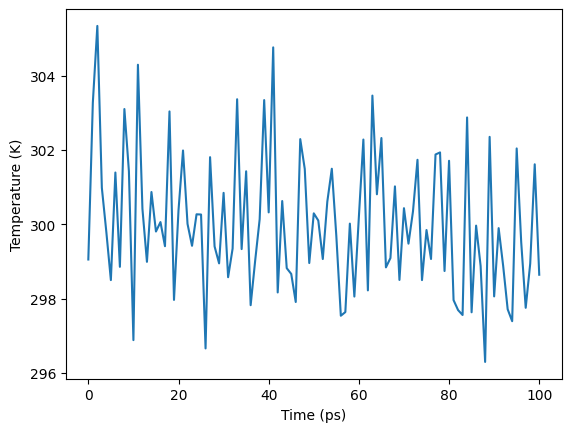

In [ ]:
# data visualization
import re
import numpy as np
import matplotlib.pyplot as plt

x_data = []
y_data = []
file = open('temperature.xvg', 'r')

for line in file:
  # extract axis labels
  line = line.strip( )
  if "xaxis" in line:
      xaxis = line.split("\"")[1]
  elif "yaxis" in line:
      yaxis = "Temperature " + line.split("\"")[1]

  # store data values for the axes
  "\"".join(line)
  if not line.startswith(('#','@')):
      x_data.append(float(re.split("\s+", line)[0]))
      y_data.append(float(re.split("\s+", line)[1]))

#graph
plt.plot(x_data, y_data)
plt.xlabel(xaxis)
plt.ylabel(yaxis)
plt.show()


In [ ]:
%%bash
source /usr/local/gromacs/bin/GMXRC
gmx grompp -f npt.mdp -c nvt.gro -r nvt.gro -t nvt.cpt -p topol.top -o npt.tpr

Setting the LD random seed to -777675883

Generated 330891 of the 330891 non-bonded parameter combinations

Generated 330891 of the 330891 1-4 parameter combinations

Excluding 3 bonded neighbours molecule type 'Protein_chain_A'

turning H bonds into constraints...

Excluding 2 bonded neighbours molecule type 'SOL'

turning H bonds into constraints...

Excluding 1 bonded neighbours molecule type 'CL'

turning H bonds into constraints...

The center of mass of the position restraint coord's is  3.485  3.520  3.499

The center of mass of the position restraint coord's is  3.485  3.520  3.499
Analysing residue names:
There are:   129    Protein residues
There are: 10636      Water residues
There are:     8        Ion residues
Analysing Protein...

The largest distance between excluded atoms is 0.445 nm between atom 1156 and 1405

Determining Verlet buffer for a tolerance of 0.005 kJ/mol/ps at 300 K

Calculated rlist for 1x1 atom pair-list as 1.035 nm, buffer size 0.035 nm

Set rlist, assu

                      :-) GROMACS - gmx grompp, 2023.2 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content
Command line:
  gmx grompp -f npt.mdp -c nvt.gro -r nvt.gro -t nvt.cpt -p topol.top -o npt.tpr

Ignoring obsolete mdp entry 'title'
Ignoring obsolete mdp entry 'ns_type'
Generating 1-4 interactions: fudge = 0.5

NOTE 1 [file topol.top, line 18410]:
  You are combining position restraints with Parrinello-Rahman pressure
  coupling, which can lead to instabilities. If you really want to combine
  position restraints with pressure coupling, we suggest to use Berendsen
  pressure coupling instead.

Number of degrees of freedom in T-Coupling group Protein is 4920.79
Number of degrees of freedom in T-Coupling group non-Protein is 63837.21

NOTE 2 [file npt.mdp]:
  Removing center of mass motion in the presence of position restraints
  might cause artifacts. When you are using position restraints to
  equilibrate a macro-molecule, the art

In [ ]:
%%bash
source /usr/local/gromacs/bin/GMXRC
gmx mdrun -v -deffnm npt

                      :-) GROMACS - gmx mdrun, 2023.2 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content
Command line:
  gmx mdrun -v -deffnm npt

Reading file npt.tpr, VERSION 2023.2 (single precision)
Changing nstlist from 10 to 50, rlist from 1 to 1.115

Using 1 MPI thread
Using 2 OpenMP threads 

starting mdrun 'LYSOZYME in water'
50000 steps,    100.0 ps.
step 49900, remaining wall clock time:     3 s          
Writing final coordinates.
step 50000, remaining wall clock time:     0 s          
               Core t (s)   Wall t (s)        (%)
       Time:     3318.841     1659.421      200.0
                 (ns/day)    (hour/ns)
Performance:        5.207        4.609

GROMACS reminds you: "Get Down In 3D" (George Clinton)



In [ ]:
%%bash
source /usr/local/gromacs/bin/GMXRC
printf "18.0" | gmx energy -f npt.edr -o pressure.xvg


Statistics over 50001 steps [ 0.0000 through 100.0000 ps ], 1 data sets
All statistics are over 501 points

Energy                      Average   Err.Est.       RMSD  Tot-Drift
-------------------------------------------------------------------------------
Pressure                   -4.39257        1.4    209.368   -7.05262  (bar)


                      :-) GROMACS - gmx energy, 2023.2 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content
Command line:
  gmx energy -f npt.edr -o pressure.xvg

Opened npt.edr as single precision energy file

Select the terms you want from the following list by
selecting either (part of) the name or the number or a combination.
End your selection with an empty line or a zero.
-------------------------------------------------------------------
  1  Bond             2  Angle            3  Proper-Dih.      4  Ryckaert-Bell.
  5  LJ-14            6  Coulomb-14       7  LJ-(SR)          8  Disper.-corr. 
  9  Coulomb-(SR)    10  Coul.-recip.    11  Position-Rest.  12  Potential     
 13  Kinetic-En.     14  Total-Energy    15  Conserved-En.   16  Temperature   
 17  Pres.-DC        18  Pressure        19  Constr.-rmsd    20  Box-X         
 21  Box-Y           22  Box-Z           23  Volume          24  Density       
 25  pV              2

<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3840/499059482.py:21: SyntaxWarning: invalid escape sequence '\s'
  x_data.append(float(re.split("\s+", line)[0]))
/tmp/ipykernel_3840/499059482.py:22: SyntaxWarning: invalid escape sequence '\s'
  y_data.append(float(re.split("\s+", line)[1]))


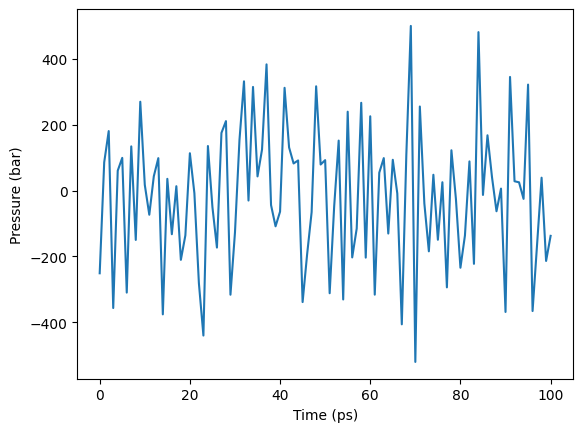

In [ ]:
# data visualization
import re
import numpy as np
import matplotlib.pyplot as plt

x_data = []
y_data = []
file = open('pressure.xvg', 'r')

for line in file:
  # extract axis labels
  line = line.strip( )
  if "xaxis" in line:
      xaxis = line.split("\"")[1]
  elif "yaxis" in line:
      yaxis = "Pressure " + line.split("\"")[1]

  # store data values for the axes
  "\"".join(line)
  if not line.startswith(('#','@')):
      x_data.append(float(re.split("\s+", line)[0]))
      y_data.append(float(re.split("\s+", line)[1]))

#graph
plt.plot(x_data, y_data)
plt.xlabel(xaxis)
plt.ylabel(yaxis)
plt.show()


In [ ]:
# density
%%bash
source /usr/local/gromacs/bin/GMXRC
printf "24.0" | gmx energy -f npt.edr -o density.xvg


Statistics over 50001 steps [ 0.0000 through 100.0000 ps ], 1 data sets
All statistics are over 501 points

Energy                      Average   Err.Est.       RMSD  Tot-Drift
-------------------------------------------------------------------------------
Density                     1018.82       0.36    5.13266   -0.76536  (kg/m^3)


                      :-) GROMACS - gmx energy, 2023.2 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content
Command line:
  gmx energy -f npt.edr -o density.xvg

Opened npt.edr as single precision energy file

Select the terms you want from the following list by
selecting either (part of) the name or the number or a combination.
End your selection with an empty line or a zero.
-------------------------------------------------------------------
  1  Bond             2  Angle            3  Proper-Dih.      4  Ryckaert-Bell.
  5  LJ-14            6  Coulomb-14       7  LJ-(SR)          8  Disper.-corr. 
  9  Coulomb-(SR)    10  Coul.-recip.    11  Position-Rest.  12  Potential     
 13  Kinetic-En.     14  Total-Energy    15  Conserved-En.   16  Temperature   
 17  Pres.-DC        18  Pressure        19  Constr.-rmsd    20  Box-X         
 21  Box-Y           22  Box-Z           23  Volume          24  Density       
 25  pV              26

<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3840/3502448704.py:21: SyntaxWarning: invalid escape sequence '\s'
  x_data.append(float(re.split("\s+", line)[0]))
/tmp/ipykernel_3840/3502448704.py:22: SyntaxWarning: invalid escape sequence '\s'
  y_data.append(float(re.split("\s+", line)[1]))


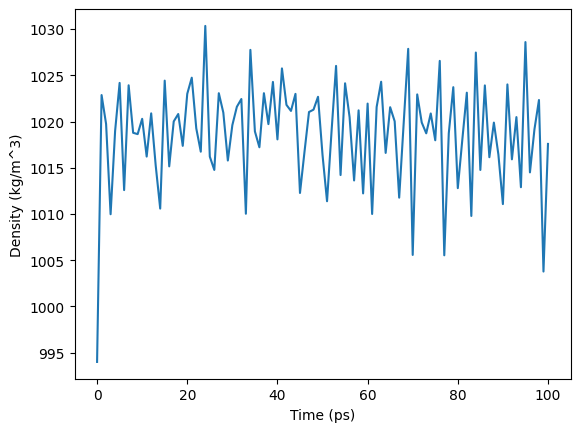

In [ ]:
# data visualization
import re
import numpy as np
import matplotlib.pyplot as plt

x_data = []
y_data = []
file = open('density.xvg', 'r')

for line in file:
  # extract axis labels
  line = line.strip( )
  if "xaxis" in line:
      xaxis = line.split("\"")[1]
  elif "yaxis" in line:
      yaxis = "Density " + line.split("\"")[1]

  # store data values for the axes
  "\"".join(line)
  if not line.startswith(('#','@')):
      x_data.append(float(re.split("\s+", line)[0]))
      y_data.append(float(re.split("\s+", line)[1]))

#graph
plt.plot(x_data, y_data)
plt.xlabel(xaxis)
plt.ylabel(yaxis)
plt.show()


Etapa 6 - Produção

**Nota de Esclarecimento**: Devido às restrições de tempo de execução e recursos da versão gratuita do Google Colab, os parâmetros desta simulação foram intencionalmente ajustados para uma produção de curto prazo. O objetivo principal deste documento é demonstrar o domínio do fluxo de trabalho (pipeline), automação de comandos do GROMACS e análise de dados estruturais.

Em um ambiente de produção ou pesquisa real, a mesma metodologia seria aplicada para escalas de tempo de nanossegundos ou microssegundos.

In [ ]:
# md.mdp configuration
md_config = """title                   = OPLS Lysozyme NPT equilibration
; Run parameters
integrator              = md        ; leap-frog integrator
nsteps                  = 500000  ; 2 * 500000 = 1000 ps (1 ns)
dt                      = 0.002     ; 2 fs
; Output control
nstxout                 = 0         ; suppress bulky .trr file by specifying
nstvout                 = 0         ; 0 for output frequency of nstxout,
nstfout                 = 0         ; nstvout, and nstfout
nstenergy               = 500      ; save energies every 1.0 ps
nstlog                  = 500      ; update log file every 1.0 ps
nstxout-compressed      = 500      ; save compressed coordinates every 1.0 ps
compressed-x-grps       = System    ; save the whole system
; Bond parameters
continuation            = yes       ; Restarting after NPT
constraint_algorithm    = lincs     ; holonomic constraints
constraints             = h-bonds   ; bonds involving H are constrained
lincs_iter              = 1         ; accuracy of LINCS
lincs_order             = 4         ; also related to accuracy
; Neighborsearching
cutoff-scheme           = Verlet    ; Buffered neighbor searching
ns_type                 = grid      ; search neighboring grid cells
nstlist                 = 10        ; 20 fs, largely irrelevant with Verlet scheme
rcoulomb                = 1.0       ; short-range electrostatic cutoff (in nm)
rvdw                    = 1.0       ; short-range van der Waals cutoff (in nm)
; Electrostatics
coulombtype             = PME       ; Particle Mesh Ewald for long-range electrostatics
pme_order               = 4         ; cubic interpolation
fourierspacing          = 0.16      ; grid spacing for FFT
; Temperature coupling is on
tcoupl                  = V-rescale             ; modified Berendsen thermostat
tc-grps                 = Protein Non-Protein   ; two coupling groups - more accurate
tau_t                   = 0.1     0.1           ; time constant, in ps
ref_t                   = 300     300           ; reference temperature, one for each group, in K
; Pressure coupling is on
pcoupl                  = Parrinello-Rahman     ; Pressure coupling on in NPT
pcoupltype              = isotropic             ; uniform scaling of box vectors
tau_p                   = 2.0                   ; time constant, in ps
ref_p                   = 1.0                   ; reference pressure, in bar
compressibility         = 4.5e-5                ; isothermal compressibility of water, bar^-1
; Periodic boundary conditions
pbc                     = xyz       ; 3-D PBC
; Dispersion correction
DispCorr                = EnerPres  ; account for cut-off vdW scheme
; Velocity generation
gen_vel                 = no        ; Velocity generation is off
"""
with open('md.mdp', 'w') as f:
    f.write(md_config)
!cat md.mdp

title                   = OPLS Lysozyme NPT equilibration
; Run parameters
integrator              = md        ; leap-frog integrator
nsteps                  = 500000  ; 2 * 500000 = 1000 ps (1 ns)
dt                      = 0.002     ; 2 fs
; Output control
nstxout                 = 0         ; suppress bulky .trr file by specifying
nstvout                 = 0         ; 0 for output frequency of nstxout,
nstfout                 = 0         ; nstvout, and nstfout
nstenergy               = 500      ; save energies every 1.0 ps
nstlog                  = 500      ; update log file every 1.0 ps
nstxout-compressed      = 500      ; save compressed coordinates every 1.0 ps
compressed-x-grps       = System    ; save the whole system
; Bond parameters
continuation            = yes       ; Restarting after NPT
constraint_algorithm    = lincs     ; holonomic constraints
constraints             = h-bonds   ; bonds involving H are constrained
lincs_iter              = 1         ; accuracy of LINCS


In [ ]:
%%bash
source /usr/local/gromacs/bin/GMXRC
gmx grompp -f md.mdp -c npt.gro -t npt.cpt -p topol.top -o md_0_1.tpr

Setting the LD random seed to 1541357551

Generated 330891 of the 330891 non-bonded parameter combinations

Generated 330891 of the 330891 1-4 parameter combinations

Excluding 3 bonded neighbours molecule type 'Protein_chain_A'

turning H bonds into constraints...

Excluding 2 bonded neighbours molecule type 'SOL'

turning H bonds into constraints...

Excluding 1 bonded neighbours molecule type 'CL'

turning H bonds into constraints...
Analysing residue names:
There are:   129    Protein residues
There are: 10636      Water residues
There are:     8        Ion residues
Analysing Protein...

The largest distance between excluded atoms is 0.451 nm between atom 1156 and 1405

Determining Verlet buffer for a tolerance of 0.005 kJ/mol/ps at 300 K

Calculated rlist for 1x1 atom pair-list as 1.035 nm, buffer size 0.035 nm

Set rlist, assuming 4x4 atom pair-list, to 1.000 nm, buffer size 0.000 nm

Note that mdrun will redetermine rlist based on the actual pair-list setup

Reading Coordinates,

                      :-) GROMACS - gmx grompp, 2023.2 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content
Command line:
  gmx grompp -f md.mdp -c npt.gro -t npt.cpt -p topol.top -o md_0_1.tpr

Ignoring obsolete mdp entry 'title'
Ignoring obsolete mdp entry 'ns_type'
Generating 1-4 interactions: fudge = 0.5
Number of degrees of freedom in T-Coupling group Protein is 4920.79
Number of degrees of freedom in T-Coupling group non-Protein is 63837.21
Last frame         -1 time  100.000   

GROMACS reminds you: "Don't Push Me, Cause I'm Close to the Edge" (Tricky)



In [ ]:
%%bash
source /usr/local/gromacs/bin/GMXRC
#with cpu
gmx mdrun -deffnm md_0_1 -v
#with gpu
#gmx mdrun -deffnm md_0_1 -v -nb gpu

                      :-) GROMACS - gmx mdrun, 2023.2 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content
Command line:
  gmx mdrun -deffnm md_0_1 -v

Reading file md_0_1.tpr, VERSION 2023.2 (single precision)
Changing nstlist from 10 to 40, rlist from 1 to 1.096

Using 1 MPI thread
Using 2 OpenMP threads 

starting mdrun 'LYSOZYME in water'
500000 steps,   1000.0 ps.
step 499900, remaining wall clock time:     3 s          
Writing final coordinates.
step 500000, remaining wall clock time:     0 s          
               Core t (s)   Wall t (s)        (%)
       Time:    33009.571    16504.789      200.0
                         4h35:04
                 (ns/day)    (hour/ns)
Performance:        5.235        4.585

GROMACS reminds you: "There's No Room For the Weak" (Joy Division)



Trazendo a proteina para o centro da caixa de simulação

In [ ]:
%%bash
source /usr/local/gromacs/bin/GMXRC
printf "Protein\nSystem\n" | gmx trjconv -s md_0_1.tpr -f md_0_1.xtc -o md_0_1_center.xtc -pbc mol -center

Note that major changes are planned in future for trjconv, to improve usability and utility.
Select group for centering
Selected 1: 'Protein'
Select group for output
Selected 0: 'System'


                     :-) GROMACS - gmx trjconv, 2023.2 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content
Command line:
  gmx trjconv -s md_0_1.tpr -f md_0_1.xtc -o md_0_1_center.xtc -pbc mol -center

Will write xtc: Compressed trajectory (portable xdr format): xtc
Reading file md_0_1.tpr, VERSION 2023.2 (single precision)
Reading file md_0_1.tpr, VERSION 2023.2 (single precision)
Group     0 (         System) has 33876 elements
Group     1 (        Protein) has  1960 elements
Group     2 (      Protein-H) has  1001 elements
Group     3 (        C-alpha) has   129 elements
Group     4 (       Backbone) has   387 elements
Group     5 (      MainChain) has   517 elements
Group     6 (   MainChain+Cb) has   634 elements
Group     7 (    MainChain+H) has   646 elements
Group     8 (      SideChain) has  1314 elements
Group     9 (    SideChain-H) has   484 elements
Group    10 (    Prot-Masses) has  1960 elements
Group    11 (    non-Prote

## Análise da Simulação de Dinâmica Molecular
* Apenas calcularei o RMSD aqui
* Para demais parâmetros de análise, RMSF, Raio de giração médio, Número total de ligações de hidrogênio e etc. Por favor, consulte a documentação do gromacs.

Referência: https://manual.gromacs.org/




In [ ]:
%%bash
source /usr/local/gromacs/bin/GMXRC
printf "Backbone\nSystem\n" | gmx rms -s md_0_1.tpr -f md_0_1_center.xtc -o rmsd.xvg -tu ns

Selected 4: 'Backbone'
Selected 0: 'System'


                       :-) GROMACS - gmx rms, 2023.2 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content
Command line:
  gmx rms -s md_0_1.tpr -f md_0_1_center.xtc -o rmsd.xvg -tu ns

Reading file md_0_1.tpr, VERSION 2023.2 (single precision)
Reading file md_0_1.tpr, VERSION 2023.2 (single precision)
Select group for least squares fit
Group     0 (         System) has 33876 elements
Group     1 (        Protein) has  1960 elements
Group     2 (      Protein-H) has  1001 elements
Group     3 (        C-alpha) has   129 elements
Group     4 (       Backbone) has   387 elements
Group     5 (      MainChain) has   517 elements
Group     6 (   MainChain+Cb) has   634 elements
Group     7 (    MainChain+H) has   646 elements
Group     8 (      SideChain) has  1314 elements
Group     9 (    SideChain-H) has   484 elements
Group    10 (    Prot-Masses) has  1960 elements
Group    11 (    non-Protein) has 31916 elements
Group    12 (          Wa

<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3840/882699709.py:21: SyntaxWarning: invalid escape sequence '\s'
  x_data.append(float(re.split("\s+", line)[0]))
/tmp/ipykernel_3840/882699709.py:22: SyntaxWarning: invalid escape sequence '\s'
  y_data.append(float(re.split("\s+", line)[1]))


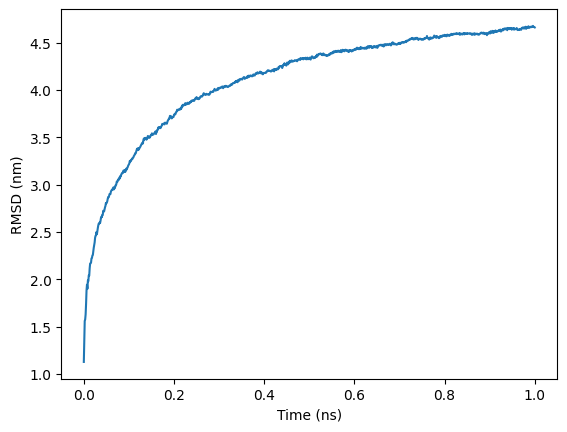

In [ ]:
# data visualization
import re
import numpy as np
import matplotlib.pyplot as plt

x_data = []
y_data = []
file = open('rmsd.xvg', 'r')

for line in file:
  # extract axis labels
  line = line.strip( )
  if "xaxis" in line:
      xaxis = line.split("\"")[1]
  elif "yaxis" in line:
      yaxis = line.split("\"")[1]

  # store data values for the axes
  "\"".join(line)
  if not line.startswith(('#','@')):
      x_data.append(float(re.split("\s+", line)[0]))
      y_data.append(float(re.split("\s+", line)[1]))

#graph
plt.plot(x_data, y_data)
plt.xlabel(xaxis)
plt.ylabel(yaxis)
plt.show()